# Centroid loss — no double perturbations in training — Norman 2019 (40 % gamma 1.1)

Re-runs two selected settings from notebook 6 with a corrected train/test split
where **all double-perturbation conditions are exclusively in the test set**,
in agreement with the discrepancy-VAE / gCRL-VAE theory.

Selected settings (from centroid grid v2 results):
- **`01_mmd20`**: best overall — lowest mean centroid distance across all three models
- **`04_mmd20_kld01`**: best for gCRL-VAE specifically — lowest gCRL-VAE centroid distance

All three models are run for each setting:
- **CMVAE-full**: `use_tf_only=False, use_GRN_priors=False, z_dim=None`
- **CMVAE-comp**: `use_tf_only=False, use_GRN_priors=False, z_dim=n_eig`
- **gCRL-VAE**:   `use_tf_only=True,  use_GRN_priors=True,  z_dim=None`


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, "../../src")

import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from gcrl.grn.eigengenes import compute_eigengenes
from gcrl.training.train_gcrl_vae import VAEConfig, train_gcrl_vae
from gcrl.evaluation.prediction_eval import evaluate_predictions

In [3]:
# Control panel
_ctrl_labels = ["unperturbed", "control", "ctrl"]

DATA_PATH = "../../data/real/Norman2019/Norman2019_processed_40pct_gamma1p1.h5ad"
BASE_DIR  = "../../results/real/Norman2019/centroid_no_double_train_40_1.1"

## 1. Load data and compute eigengenes

In [4]:
adata = ad.read_h5ad(DATA_PATH)
print(f"Loaded: {adata.shape[0]} cells × {adata.shape[1]} genes")

# Verify no double perturbations in training
double_mask = adata.obs["intervention"].str.contains("+", regex=False)
print("Double perturbations by set:")
print(adata.obs[double_mask]["set"].value_counts())

compute_eigengenes(
    adata,
    community_col="community",
    reference_query='intervention == "unperturbed"',
    mode="all_cells",
    method="PC",
    seed=42,
)
eig   = adata.obsm["X_comm_eig"]
n_eig = eig.shape[1]
print(f"Eigengene matrix: {eig.shape}  (n_cells × n_communities+1)")

Loaded: 35048 cells × 1642 genes
Double perturbations by set:
set
test        7330
training       0
Name: count, dtype: int64
Eigengene matrix: (35048, 9)  (n_cells × n_communities+1)


## 2. Define configurations

In [5]:
# Anchor: best setting from centroid grid v1 (alpha_mmd=20, all else original)
_base = dict(
    use_centroid_loss = True,
    alpha_mmd_max     = 20.0,
    beta_kld_max      = 2.0,
    lambda_sparse     = 1e-3,
    lambda_mcc        = 1.0,   # active only for gCRL-VAE; zeroed for CMVAE variants
    lr                = 1e-3,
    batch_size        = 32,
    epochs            = 100,
    seed              = 0,
)

SETTINGS = [
    ("01_mmd20",       {}),                                          # best overall
    ("04_mmd20_kld01", dict(beta_kld_max=0.1)),                      # best for gCRL-VAE
]

SUBMODELS = [
    ("cmvae_full", dict(use_tf_only=False, use_GRN_priors=False, z_dim=None)),
    ("cmvae_comp", dict(use_tf_only=False, use_GRN_priors=False, z_dim=n_eig)),
    ("gcrl_vae",   dict(use_tf_only=True,  use_GRN_priors=True,  z_dim=None)),
]

print(f"{len(SETTINGS)} settings × {len(SUBMODELS)} models = {len(SETTINGS)*len(SUBMODELS)} runs")

2 settings × 3 models = 6 runs


## 3. Train all configurations

Results saved after each run; already-completed runs are skipped on re-run.

In [6]:
models    = {}
histories = {}

for name, overrides in SETTINGS:
    for sub_name, sub_kwargs in SUBMODELS:
        key       = (name, sub_name)
        out_dir   = f"{BASE_DIR}/{name}/{sub_name}"
        hist_path = f"{out_dir}/training_history.json"

        if os.path.exists(hist_path):
            print(f"Skipping {name}/{sub_name}  (already done)")
            with open(hist_path) as f:
                histories[key] = pd.DataFrame(json.load(f))
            models[key] = None
            continue

        print(f"\n{'='*55}")
        print(f"Training: {name} / {sub_name}")
        print(f"{'='*55}")
        cfg_kwargs = {**_base, **overrides, **sub_kwargs}
        cfg = VAEConfig(outdir=out_dir, **cfg_kwargs)
        model, history = train_gcrl_vae(adata, cfg, eigengenes_key="X_comm_eig")
        models[key]    = model
        histories[key] = pd.DataFrame(history)

        os.makedirs(out_dir, exist_ok=True)
        with open(hist_path, "w") as f:
            json.dump(histories[key].to_dict(orient="list"), f)
        print(f"  History saved → {hist_path}")

print("\nAll configurations trained.")


Training: 01_mmd20 / cmvae_full
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_no_double_train_40_1.1/01_mmd20/cmvae_full/
  History saved → ../../results/real/Norman2019/centroid_no_double_train_40_1.1/01_mmd20/cmvae_full/training_history.json

Training: 01_mmd20 / cmvae_comp
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_no_double_train_40_1.1/01_mmd20/cmvae_comp/
  History saved → ../../results/real/Norman2019/centroid_no_double_train_40_1.1/01_mmd20/cmvae_comp/training_history.json

Training: 01_mmd20 / gcrl_vae
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


...

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_no_double_train_40_1.1/04_mmd20_kld01/cmvae_full/
  History saved → ../../results/real/Norman2019/centroid_no_double_train_40_1.1/04_mmd20_kld01/cmvae_full/training_history.json

Training: 04_mmd20_kld01 / cmvae_comp
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_no_double_train_40_1.1/04_mmd20_kld01/cmvae_comp/
  History saved → ../../results/real/Norman2019/centroid_no_double_train_40_1.1/04_mmd20_kld01/cmvae_comp/training_history.json

Training: 04_mmd20_kld01 / gcrl_vae
gCRL-VAE Training
  Device : cuda
  GPU    : NVIDIA RTX A4500


gCRL-VAE:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training complete. Last model returned; both models saved to ../../results/real/Norman2019/centroid_no_double_train_40_1.1/04_mmd20_kld01/gcrl_vae/
  History saved → ../../results/real/Norman2019/centroid_no_double_train_40_1.1/04_mmd20_kld01/gcrl_vae/training_history.json

All configurations trained.


## 4. Predict and evaluate

In [7]:
_predict_kwargs = dict(
    set_key          = "set",
    intervention_key = "intervention",
    cell_type_key    = "cell_type",
    control_labels   = tuple(_ctrl_labels),
    seed             = 42,
)

metrics = {}

for name, _ in SETTINGS:
    for sub_name, _ in SUBMODELS:
        key      = (name, sub_name)
        out_dir  = f"{BASE_DIR}/{name}/{sub_name}"
        csv_path = f"{out_dir}/prediction_metrics.csv"

        if os.path.exists(csv_path):
            print(f"Skipping eval {name}/{sub_name}  (already done)")
            metrics[key] = pd.read_csv(csv_path)
            continue

        preds = models[key].predict(adata, **_predict_kwargs)
        metrics[key] = evaluate_predictions(
            adata          = adata,
            preds          = preds,
            output_dir     = out_dir,
            control_labels = tuple(_ctrl_labels),
        )
        cd = metrics[key].query("metric_name == 'centroid_distance' and method == 'actual'")["metric_value"].median()
        wc = metrics[key].query("metric_name == 'centroid_distance' and method == 'worst_case'")["metric_value"].median()
        print(f"{name}/{sub_name:<12}  actual={cd:.4f}  worst_case={wc:.4f}")

print("\nAll evaluations complete.")

01_mmd20/cmvae_full    actual=4.3241  worst_case=5.5041
01_mmd20/cmvae_comp    actual=3.9455  worst_case=5.5041
01_mmd20/gcrl_vae      actual=3.6391  worst_case=5.5041
04_mmd20_kld01/cmvae_full    actual=4.8459  worst_case=5.5041
04_mmd20_kld01/cmvae_comp    actual=3.9611  worst_case=5.5041
04_mmd20_kld01/gcrl_vae      actual=3.4797  worst_case=5.5041

All evaluations complete.


## 5. Training curves

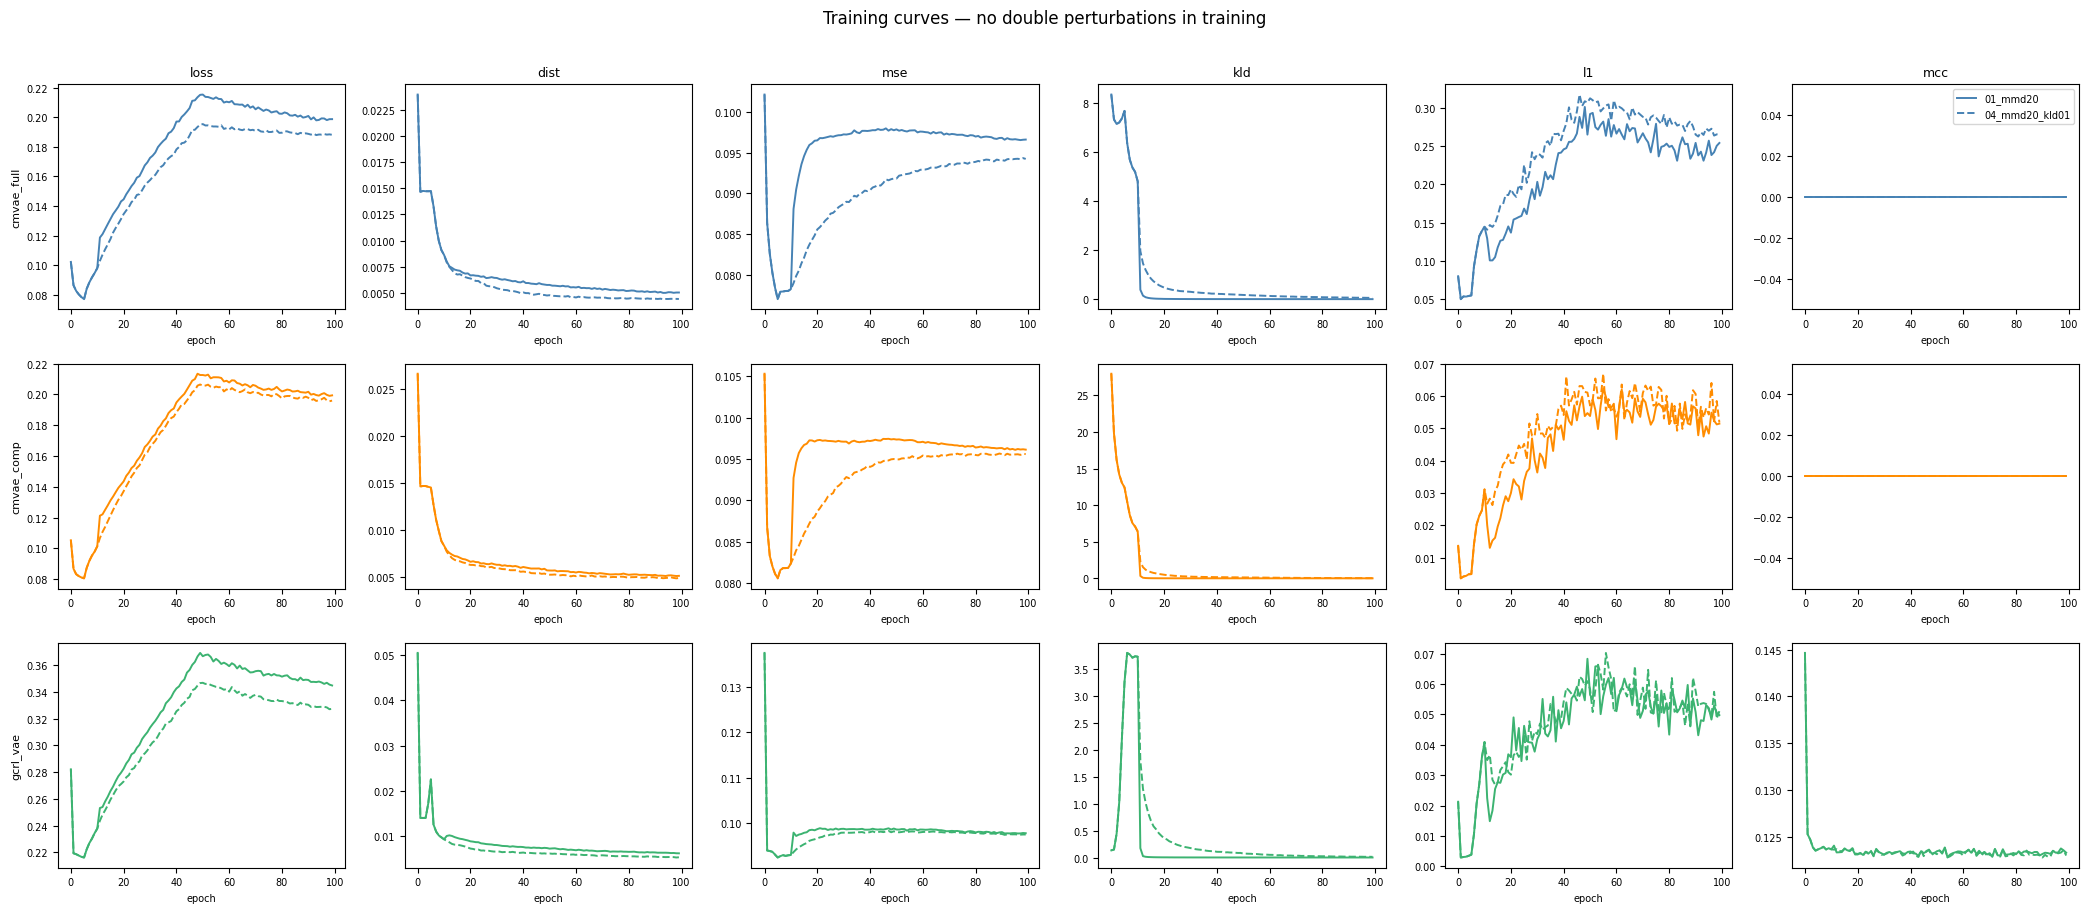

In [8]:
LOSS_COLS  = ["loss", "dist", "mse", "kld", "l1", "mcc"]
sub_colors = {"cmvae_full": "steelblue", "cmvae_comp": "darkorange", "gcrl_vae": "mediumseagreen"}
set_styles = {"01_mmd20": "-", "04_mmd20_kld01": "--"}

n_sub  = len(SUBMODELS)
n_cols = len(LOSS_COLS)
fig, axes = plt.subplots(n_sub, n_cols, figsize=(3.5 * n_cols, 3 * n_sub), squeeze=False)

for row, (sub_name, _) in enumerate(SUBMODELS):
    for col, lc in enumerate(LOSS_COLS):
        ax = axes[row, col]
        for name, _ in SETTINGS:
            df = histories[(name, sub_name)]
            if lc in df.columns:
                ax.plot(df["epoch"], df[lc],
                        label=name, color=sub_colors[sub_name],
                        linestyle=set_styles[name], linewidth=1.4)
        if row == 0:
            ax.set_title(lc, fontsize=9)
        if col == 0:
            ax.set_ylabel(sub_name, fontsize=8)
        ax.set_xlabel("epoch", fontsize=7)
        ax.tick_params(labelsize=7)
        if row == 0 and col == n_cols - 1:
            ax.legend(fontsize=7)

plt.suptitle("Training curves — no double perturbations in training", y=1.01)
plt.tight_layout()
plt.show()

## 6. Performance summary and statistical tests

For each setting, gCRL-VAE is contrasted against CMVAE-full, CMVAE-comp,
worst_case, and perfect_baseline using a two-tailed Wilcoxon signed-rank test.
Pairs matched on (cell_type, intervention).

In [9]:
def se(x):
    return x.std(ddof=1) / np.sqrt(len(x))

def paired_wilcoxon(a_df, b_df, key_cols=["cell_type", "intervention"]):
    merged = a_df.merge(b_df, on=key_cols, suffixes=("_a", "_b"))
    diff = merged["metric_value_a"] - merged["metric_value_b"]
    diff = diff[diff != 0]
    if len(diff) < 5:
        return np.nan
    _, p = wilcoxon(diff)
    return p

def sig_stars(p):
    if np.isnan(p): return ""
    return "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))

METRIC = "centroid_distance"
REFERENCES = [
    ("vs_cmvae_full", "cmvae_full", "actual"),
    ("vs_cmvae_comp", "cmvae_comp", "actual"),
    ("vs_worst_case", "gcrl_vae",   "worst_case"),
    ("vs_perfect",    "gcrl_vae",   "perfect_baseline"),
]

# Build raw slices
raw = {}
for name, _ in SETTINGS:
    for sub_name, _ in SUBMODELS:
        df = metrics[(name, sub_name)]
        df = df[df["metric_name"] == METRIC]
        for method in ["actual", "worst_case", "perfect_baseline"]:
            raw[(name, sub_name, method)] = df[df["method"] == method][
                ["cell_type", "intervention", "metric_value"]
            ].copy()

# Summary table
rows = []
for name, _ in SETTINGS:
    for sub_name, _ in SUBMODELS:
        vals = raw[(name, sub_name, "actual")]["metric_value"]
        rows.append({"setting": name, "model": sub_name,
                     "median": vals.median(), "se": se(vals)})
summary = pd.DataFrame(rows)
pivot = summary.pivot_table(index="setting", columns="model",
                             values=["median", "se"]).round(4)
print(f"Median ± SE of {METRIC} (actual):")
pivot

Median ± SE of centroid_distance (actual):


median                             se                    
model          cmvae_comp cmvae_full gcrl_vae cmvae_comp cmvae_full gcrl_vae
setting                                                                     
01_mmd20           3.9455     4.3241   3.6391     0.7033     0.7555   0.4417
04_mmd20_kld01     3.9611     4.8459   3.4797     0.6421     0.4894   0.3716

In [10]:
# Wilcoxon tests: gCRL-VAE vs all four references
test_rows = []
for name, _ in SETTINGS:
    gcrl_df = raw[(name, "gcrl_vae", "actual")]
    for ref_label, ref_model, ref_method in REFERENCES:
        ref_df = raw[(name, ref_model, ref_method)]
        p = paired_wilcoxon(gcrl_df, ref_df)
        test_rows.append({
            "setting":     name,
            "reference":   ref_label,
            "gcrl_median": gcrl_df["metric_value"].median(),
            "gcrl_se":     se(gcrl_df["metric_value"]),
            "ref_median":  ref_df["metric_value"].median(),
            "ref_se":      se(ref_df["metric_value"]),
            "delta":       gcrl_df["metric_value"].median() - ref_df["metric_value"].median(),
            "p_value":     p,
            "sig":         sig_stars(p),
        })

tests = pd.DataFrame(test_rows)
print("Two-tailed Wilcoxon: gCRL-VAE vs reference")
print("Negative delta = gCRL-VAE has lower centroid distance\n")
for ref_label, _, _ in REFERENCES:
    sub = tests[tests["reference"] == ref_label]
    print(f"--- {ref_label} ---")
    print(sub[["setting", "gcrl_median", "gcrl_se", "ref_median", "ref_se",
               "delta", "p_value", "sig"]].to_string(index=False))
    print()

Two-tailed Wilcoxon: gCRL-VAE vs reference
Negative delta = gCRL-VAE has lower centroid distance

--- vs_cmvae_full ---
       setting  gcrl_median  gcrl_se  ref_median   ref_se     delta  p_value sig
      01_mmd20     3.639118 0.441707    4.324055 0.755526 -0.684937 0.080196  ns
04_mmd20_kld01     3.479664 0.371627    4.845901 0.489420 -1.366238 0.002508  **

--- vs_cmvae_comp ---
       setting  gcrl_median  gcrl_se  ref_median   ref_se     delta  p_value sig
      01_mmd20     3.639118 0.441707    3.945475 0.703265 -0.306357 0.219986  ns
04_mmd20_kld01     3.479664 0.371627    3.961148 0.642095 -0.481484 0.080196  ns

--- vs_worst_case ---
       setting  gcrl_median  gcrl_se  ref_median   ref_se     delta  p_value sig
      01_mmd20     3.639118 0.441707    5.504053 0.321955 -1.864935 0.002255  **
04_mmd20_kld01     3.479664 0.371627    5.504053 0.321955 -2.024389 0.000075 ***

--- vs_perfect ---
       setting  gcrl_median  gcrl_se  ref_median  ref_se    delta      p_value sig
  

## 7. Bar chart: median centroid distance with SE

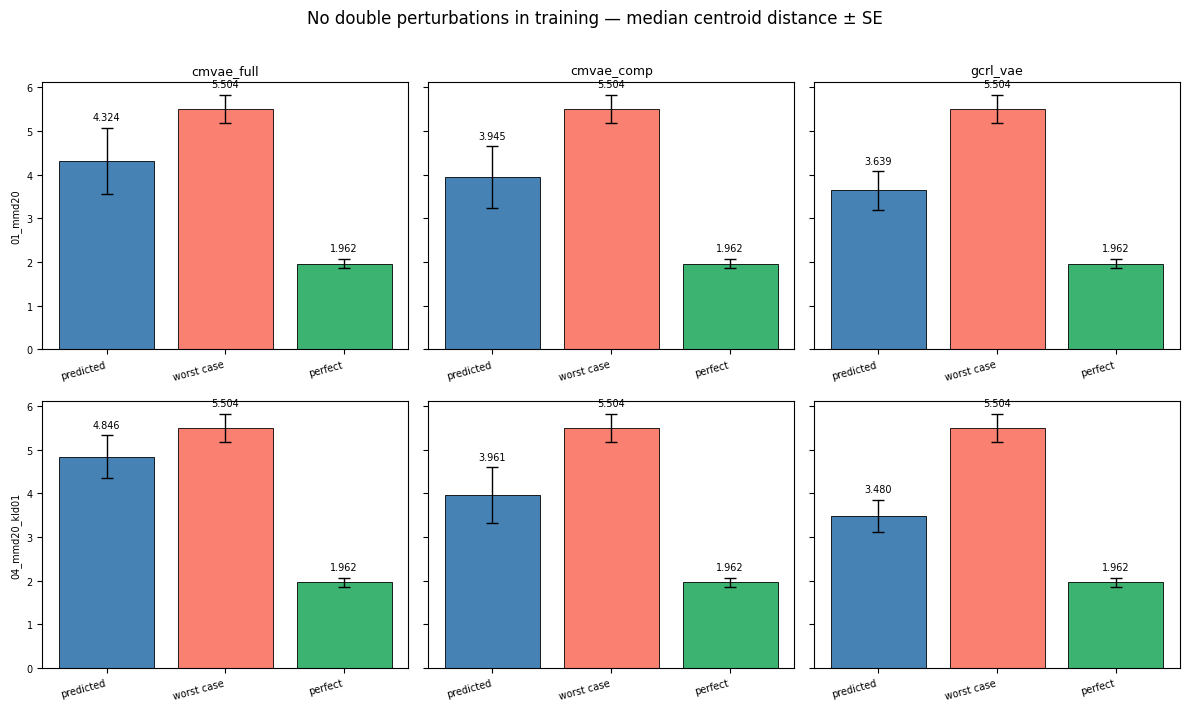

In [11]:
methods_order = ["actual", "worst_case", "perfect_baseline"]
method_colors = {"actual": "steelblue", "worst_case": "salmon", "perfect_baseline": "mediumseagreen"}
model_order   = [s for s, _ in SUBMODELS]

n_set = len(SETTINGS)
n_sub = len(SUBMODELS)
fig, axes = plt.subplots(n_set, n_sub, figsize=(4 * n_sub, 3.5 * n_set),
                         sharey="row", squeeze=False)

for row, (name, _) in enumerate(SETTINGS):
    for col, (sub_name, _) in enumerate(SUBMODELS):
        ax = axes[row, col]
        bar_vals, bar_ses = [], []
        for method in methods_order:
            vals = raw[(name, sub_name, method)]["metric_value"]
            bar_vals.append(vals.median())
            bar_ses.append(se(vals))
        bars = ax.bar(
            range(len(methods_order)), bar_vals,
            yerr=bar_ses, capsize=4,
            color=[method_colors[m] for m in methods_order],
            edgecolor="k", linewidth=0.6,
            error_kw=dict(elinewidth=1, ecolor="black"),
        )
        ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=7)
        ax.set_xticks(range(len(methods_order)))
        ax.set_xticklabels(["predicted", "worst case", "perfect"],
                           rotation=15, ha="right", fontsize=7)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(name, fontsize=7)
        if row == 0:
            ax.set_title(sub_name, fontsize=9)

plt.suptitle("No double perturbations in training — median centroid distance ± SE", y=1.01)
plt.tight_layout()
plt.show()